# **Import library, load dataset, mencari total data mentah**

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

# Lokasi file dataset
file_path = '/content/taxi_dataset.csv'

print("--- Memulai Proses Extract ---")
start_time = time.time()

# Membaca dataset
df_raw = pd.read_csv(file_path, low_memory=False)

end_time = time.time()
print(f"Data berhasil dimuat dalam {end_time - start_time:.2f} detik.")
print(f"Jumlah baris mentah: {len(df_raw):,}")
display(df_raw.head())

--- Memulai Proses Extract ---
Data berhasil dimuat dalam 55.84 detik.
Jumlah baris mentah: 11,916,667


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.2,1.0,N,238.0,239.0,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.2,1.0,N,239.0,238.0,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.6,1.0,N,238.0,238.0,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.8,1.0,N,238.0,151.0,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.0,1.0,N,193.0,193.0,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


# **3.1 Analisis Kualitas Data (Data Quality Analysis)**

### **3.1.1 Identifikasi Missing Values**

In [ ]:
print("\n--- Informasi Dataset ---")
df_raw.info()


--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11916667 entries, 0 to 11916666
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               object 
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           float64
 8   DOLocationID           float64
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(14), object(4)
memory usage: 1.6+ GB


**Cek Missing Value**

In [ ]:
print("\n--- Missing Value ---")
missing_values = df_raw.isnull().sum()

display(missing_values[missing_values > 0])


--- Missing Value ---


,0
VendorID,91448
tpep_pickup_datetime,5
tpep_dropoff_datetime,5
passenger_count,91453
trip_distance,5
RatecodeID,91453
store_and_fwd_flag,91453
PULocationID,5
DOLocationID,5
payment_type,91453


**Cek Data Duplicate**

In [ ]:
print("\n--- Data Duplikat ---")
duplicates = df_raw.duplicated().sum()

print(f"Jumlah data duplikat: {duplicates}")


--- Data Duplikat ---
Jumlah data duplikat: 12949


**Cleaning Missing Value & Duplicate**

In [ ]:
# Menghapus missing value
df_clean = df_raw.dropna()

# Menghapus data duplikat
df_clean = df_clean.drop_duplicates()

print("\n--- Dataset Setelah Cleaning ---")
print(f"Jumlah data setelah cleaning: {len(df_clean):,}")


--- Dataset Setelah Cleaning ---
Jumlah data setelah cleaning: 11,825,214


### **3.1.2 Identifikasi & Reduksi Anomali (Outlier)**

**Cek Anomali**

In [ ]:
print("\n--- Identifikasi Anomali ---")

anomali_trip = (df_clean['trip_distance'] <= 0).sum()
anomali_passenger = (df_clean['passenger_count'] <= 0).sum()
anomali_fare = (df_clean['fare_amount'] <= 0).sum()
anomali_total = (df_clean['total_amount'] <= 0).sum()

print(f"Trip distance <= 0 : {anomali_trip}")
print(f"Passenger count <= 0 : {anomali_passenger}")
print(f"Fare amount <= 0 : {anomali_fare}")
print(f"Total amount <= 0 : {anomali_total}")


--- Identifikasi Anomali ---
Trip distance <= 0 : 121161
Passenger count <= 0 : 222229
Fare amount <= 0 : 41819
Total amount <= 0 : 39890


**Reduksi Anomali**

In [ ]:
df_clean = df_clean[
    (df_clean['trip_distance'] > 0) &
    (df_clean['passenger_count'] > 0) &
    (df_clean['fare_amount'] > 0) &
    (df_clean['total_amount'] > 0)
]

print("\n--- Dataset Setelah Reduksi Anomali ---")
print(f"Jumlah data setelah reduksi anomali: {len(df_clean):,}")


--- Dataset Setelah Reduksi Anomali ---
Jumlah data setelah reduksi anomali: 11,450,739


**Reduksi Outlier Ekstrem**

In [ ]:
df_clean = df_clean[
    (df_clean['trip_distance'] < 50) &
    (df_clean['fare_amount'] < 300) &
    (df_clean['total_amount'] < 300)
]

print("\n--- Dataset Setelah Reduksi Outlier ---")
print(f"Jumlah data final: {len(df_clean):,}")


--- Dataset Setelah Reduksi Outlier ---
Jumlah data final: 11,449,953


**Ringkasan Jumlah Data**

### **3.1.3 Kondisi Data Final**

In [ ]:
raw_count = len(df_raw)

after_missing = len(
    df_raw.dropna().drop_duplicates()
)

final_count = len(df_clean)

summary = pd.DataFrame({
    'Kondisi Dataset': [
        'Dataset mentah (raw data)',
        'Setelah missing value cleaning',
        'Dataset final modeling'
    ],
    'Jumlah Data': [
        raw_count,
        after_missing,
        final_count
    ]
})

display(summary)

,Kondisi Dataset,Jumlah Data
0,Dataset mentah (raw data),11916667
1,Setelah missing value cleaning,11825214
2,Dataset final modeling,11449953


# **3.2 Analisis Deskriptif Data (Data Descriptive Analysis)**

### **3.2.1 Karakteristik Perjalanan - statistik deskriptif**

In [ ]:
print("\n--- Statistik Deskriptif Dataset Final ---")

numeric_columns = [
    'trip_distance',
    'fare_amount',
    'total_amount',
    'passenger_count'
]

display(df_clean[numeric_columns].describe())


--- Statistik Deskriptif Dataset Final ---


,trip_distance,fare_amount,total_amount,passenger_count
count,1.144995e+07,1.144995e+07,1.144995e+07,1.144995e+07
mean,2.854736e+00,1.239289e+01,1.841093e+01,1.542210e+00
std,3.681872e+00,1.081724e+01,1.348015e+01,1.143659e+00
min,1.000000e-02,1.000000e-02,3.100000e-01,1.000000e+00
25%,9.800000e-01,6.500000e+00,1.116000e+01,1.000000e+00
50%,1.600000e+00,9.000000e+00,1.430000e+01,1.000000e+00
75%,2.900000e+00,1.350000e+01,1.956000e+01,2.000000e+00
max,4.994000e+01,2.990000e+02,2.993000e+02,9.000000e+00


### **Histogram Trip Distance**

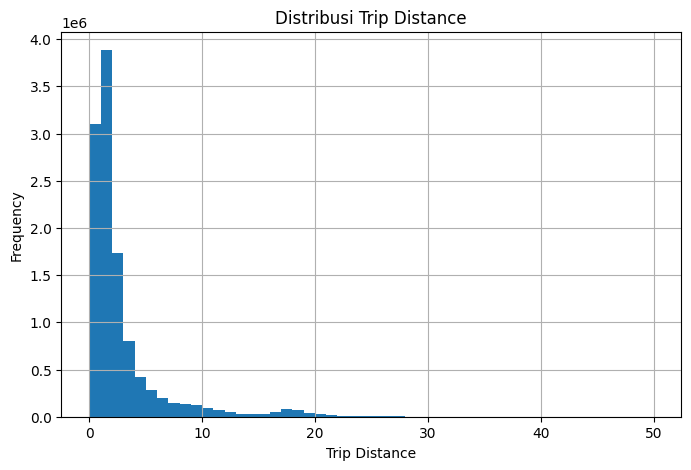

In [ ]:
plt.figure(figsize=(8,5))

df_clean['trip_distance'].hist(bins=50)

plt.xlabel('Trip Distance')
plt.ylabel('Frequency')
plt.title('Distribusi Trip Distance')

plt.show()

### **Boxplot Trip Distance**

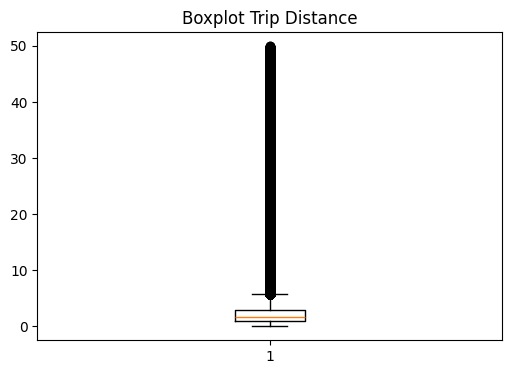

In [ ]:
plt.figure(figsize=(6,4))

plt.boxplot(df_clean['trip_distance'])

plt.title('Boxplot Trip Distance')

plt.show()

### **Scatter Plot**

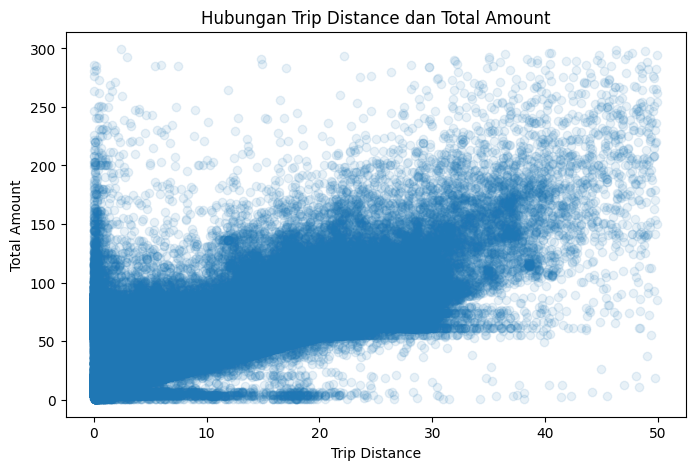

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_clean['trip_distance'],
    df_clean['total_amount'],
    alpha=0.1
)

plt.xlabel('Trip Distance')
plt.ylabel('Total Amount')

plt.title(
    'Hubungan Trip Distance dan Total Amount'
)

plt.show()

# **3.2.2 Tren Waktu dan Kesibukan**

## **2.4.1 Ekstraksi Waktu (Time Extraction)**

In [ ]:
df_clean['tpep_pickup_datetime'] = pd.to_datetime(
    df_clean['tpep_pickup_datetime'],
    format='%m/%d/%Y %I:%M:%S %p'
)

df_clean['pickup_hour'] = (
    df_clean['tpep_pickup_datetime'].dt.hour
)

df_clean['pickup_day'] = (
    df_clean['tpep_pickup_datetime'].dt.day_name()
)

display(
    df_clean[
        [
            'tpep_pickup_datetime',
            'pickup_hour',
            'pickup_day'
        ]
    ].head()
)

,tpep_pickup_datetime,pickup_hour,pickup_day
0,2020-01-01 00:28:15,0,Wednesday
1,2020-01-01 00:35:39,0,Wednesday
2,2020-01-01 00:47:41,0,Wednesday
3,2020-01-01 00:55:23,0,Wednesday
5,2020-01-01 00:09:44,0,Wednesday


### **Analisis Jam Sibuk**

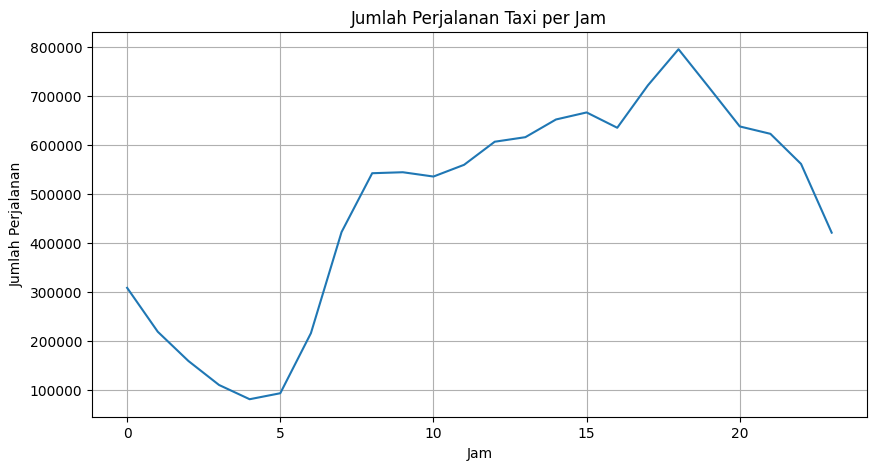

In [ ]:
hourly_trip = (
    df_clean.groupby('pickup_hour')
    .size()
)

plt.figure(figsize=(10,5))

hourly_trip.plot(kind='line')

plt.xlabel('Jam')
plt.ylabel('Jumlah Perjalanan')

plt.title(
    'Jumlah Perjalanan Taxi per Jam'
)

plt.grid(True)

plt.show()

### **Analisis Hari Tersibuk**

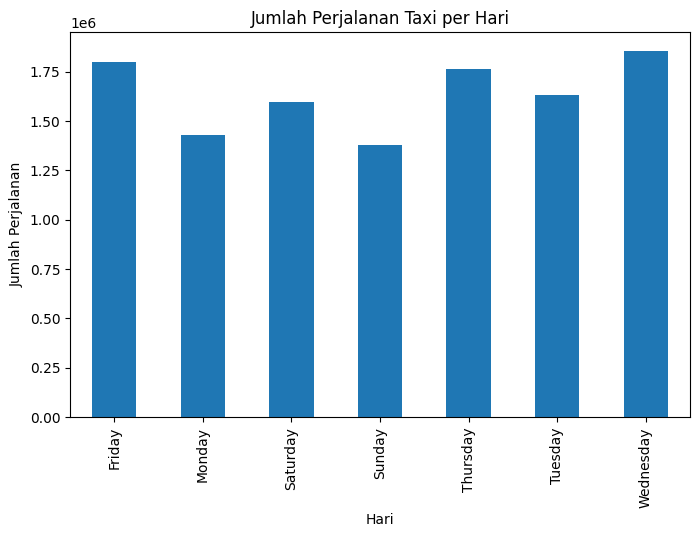

In [ ]:
daily_trip = (
    df_clean.groupby('pickup_day')
    .size()
)

plt.figure(figsize=(8,5))

daily_trip.plot(kind='bar')

plt.xlabel('Hari')
plt.ylabel('Jumlah Perjalanan')

plt.title(
    'Jumlah Perjalanan Taxi per Hari'
)

plt.show()

# **3.2.3 Distribusi Metode Pembayaran**

### **Mapping Payment Type**

In [ ]:
payment_mapping = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown'
}

df_clean['payment_type_name'] = (
    df_clean['payment_type']
    .map(payment_mapping)
)

### **Distribusi Payment Type**

In [ ]:
payment_dist = (
    df_clean['payment_type_name']
    .value_counts()
)

display(payment_dist)

,count
payment_type_name,
Credit Card,8582876
Cash,2816000
No Charge,37222
Dispute,13855


### **Bar Chart Payment Type**



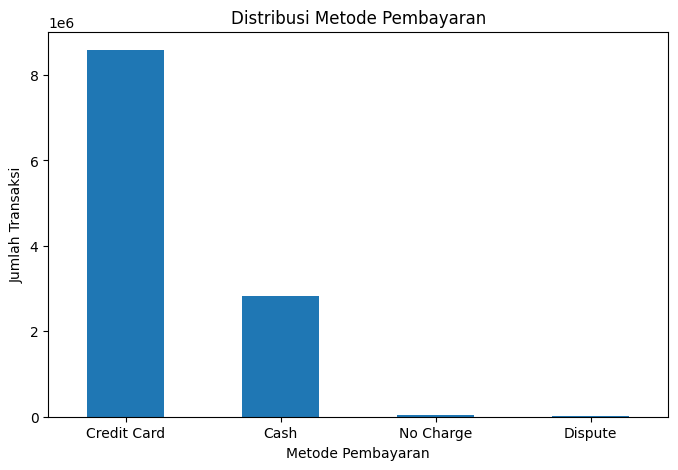

In [ ]:
plt.figure(figsize=(8,5))

payment_dist.plot(kind='bar')

plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')

plt.title('Distribusi Metode Pembayaran')

plt.xticks(rotation=0)

plt.show()

### **Rata-rata Tarif per Payment Type**

In [ ]:
avg_payment = (
    df_clean.groupby(
        'payment_type_name'
    )['total_amount']
    .mean()
)

display(avg_payment)

,total_amount
payment_type_name,
Cash,15.576359
Credit Card,19.346459
Dispute,18.190195
No Charge,17.220856


# **3.3 Analisis Clustering (Diagnosis/Predictive)**

### **Import K-Means**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### **Sampling Dataset**

### Data Sampling

Dataset terdiri dari lebih dari 11 juta record sehingga proses clustering dilakukan pada sampel acak sebanyak 50.000 data untuk mengurangi waktu komputasi.

In [ ]:
sample_df = df_clean.sample(
    n=50000,
    random_state=42
)

print(len(sample_df))

50000


### **Seleksi Fitur Clustering**

In [ ]:
features = [
    'trip_distance',
    'total_amount',
    'pickup_hour',
    'passenger_count'
]

X_sample = sample_df[features]

### **Standarisasi Data (Scaling)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_sample_scaled = scaler.fit_transform(
    X_sample
)
print(X_sample_scaled.shape)

(50000, 4)


### **Elbow Method (WCSS)**

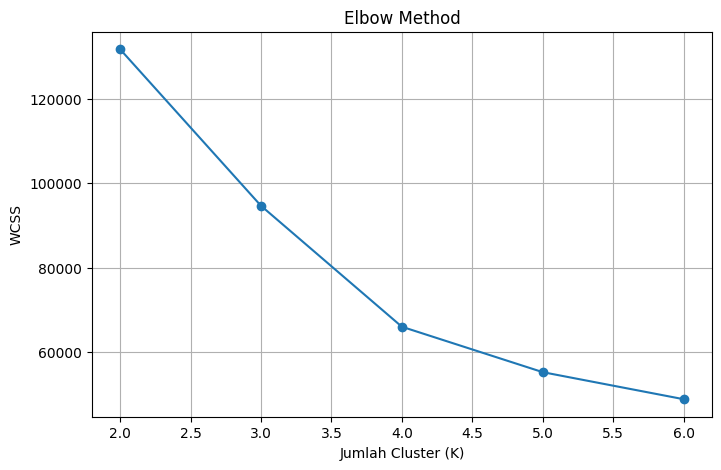

In [ ]:
wcss = []

K_range = range(2,7)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=5
    )

    kmeans.fit(X_sample_scaled)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    wcss,
    marker='o'
)

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')

plt.title('Elbow Method')

plt.grid(True)

plt.show()

### **Silhouette Score**

Nilai Silhouette Score digunakan untuk mengevaluasi kualitas cluster. Nilai sebesar 0.38 menunjukkan cluster telah terbentuk namun masih terdapat overlap karakteristik antar kelompok.


*   Sampling silhouette




In [ ]:
sample_silhouette = sample_df.sample(
    n=30000,
    random_state=42
)

In [ ]:
X_silhouette = sample_silhouette[
    features
]



*   Scaling silhouette



In [ ]:
X_silhouette_scaled = scaler.fit_transform(
    X_silhouette
)



*   Perhitungan silhouette score



In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=5
)

cluster_labels = kmeans.fit_predict(
    X_silhouette_scaled
)

silhouette_avg = silhouette_score(
    X_silhouette_scaled,
    cluster_labels
)

print(
    "Silhouette Score:",
    round(silhouette_avg, 4)
)

Silhouette Score: 0.3874


### **K-Means Final**

In [ ]:
print("\n--- K-Means Final (K=4) ---")

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=5
)

sample_df['cluster'] = (
    kmeans_final.fit_predict(
        X_sample_scaled
    )
)

display(
    sample_df[['cluster']].head()
)


--- K-Means Final (K=4) ---


,cluster
9662357,0
7874560,0
2699161,0
8190372,3
11289548,0


### **Jumlah Data Tiap Cluster**

In [ ]:
print("\n--- Jumlah Data Tiap Cluster ---")

cluster_summary = pd.DataFrame({
    'Jumlah Data':
        sample_df['cluster']
        .value_counts()
        .sort_index(),

    'Persentase (%)':
        (
            sample_df['cluster']
            .value_counts(normalize=True)
            .sort_index()
            *100
        ).round(2)
})

display(cluster_summary)


--- Jumlah Data Tiap Cluster ---


,Jumlah Data,Persentase (%)
cluster,,
0,23612,47.22
1,4371,8.74
2,3631,7.26
3,18386,36.77


### **Profil Tiap Cluster**

In [ ]:
print("\n--- Profil Tiap Cluster ---")

cluster_profile = (
    sample_df
    .groupby('cluster')[features]
    .mean()
    .round(2)
)
cluster_size = (
    sample_df['cluster']
    .value_counts()
    .sort_index()
)

display(cluster_profile)


--- Profil Tiap Cluster ---


,trip_distance,total_amount,pickup_hour,passenger_count
cluster,,,,
0,1.98,15.50,18.31,1.24
1,2.15,15.93,13.98,4.66
2,13.71,57.68,14.04,1.45
3,1.99,14.95,8.34,1.19


### **Scatter Plot Cluster**

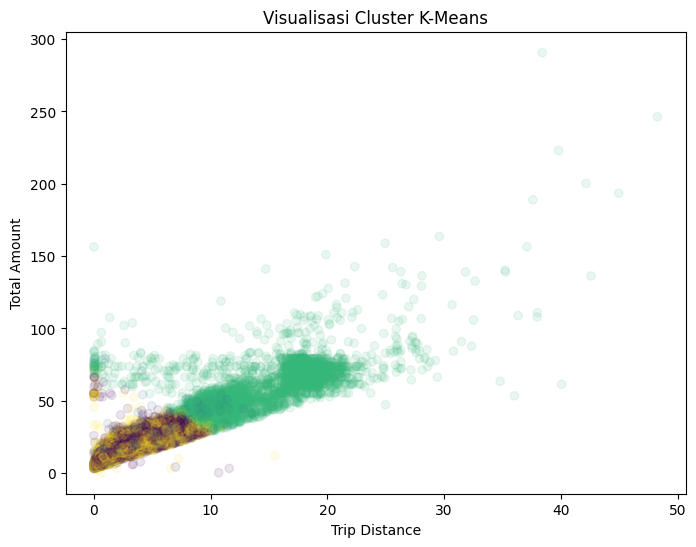

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    sample_df['trip_distance'],
    sample_df['total_amount'],
    c=sample_df['cluster'],
    alpha=0.1
)

plt.xlabel('Trip Distance')
plt.ylabel('Total Amount')

plt.title(
    'Visualisasi Cluster K-Means'
)

plt.show()

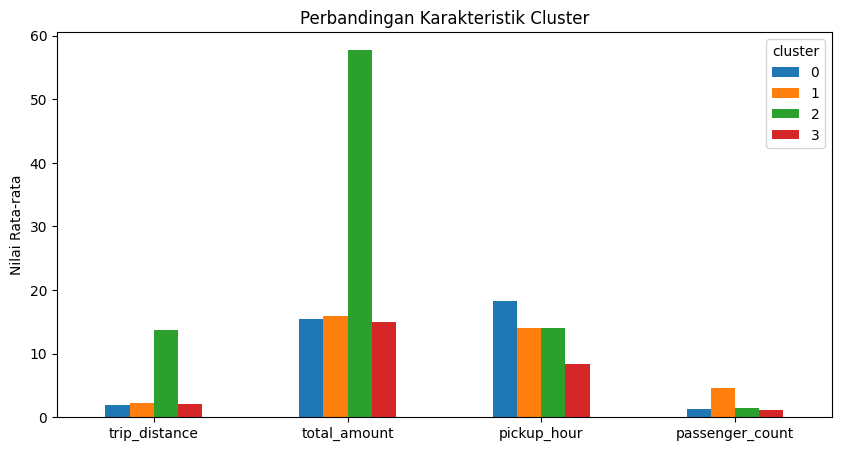

In [ ]:
cluster_profile.T.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Perbandingan Karakteristik Cluster'
)

plt.ylabel(
    'Nilai Rata-rata'
)

plt.xticks(rotation=0)

plt.show()